In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("int3_data_converted.csv")
df.shape, df.head()

((671, 4),
        I_real      I_imag   V_real  V_imag
 0  545.821931  184.174068  4.25415       0
 1  540.833093  183.878427  4.25981       0
 2  543.258921  185.146331  4.25715       0
 3  542.107563  182.501568  4.25011       0
 4  538.381423  184.510584  4.26622       0)

In [17]:
671//24

27

In [18]:
## ─── Noise Reduction ──────────────────────────────────────────────
from scipy.ndimage import gaussian_filter1d

sigma_noise = 0.5  # same as MATLAB's `sigma`
for col in ['I_real', 'I_imag', 'V_real', 'V_imag']:
    df[col] = gaussian_filter1d(df[col], sigma=sigma_noise)

## ─── Physical Feature Conversion ────────────────────────────────────
from numpy.linalg import lstsq
from scipy.stats import norm

WINDOW_SIZE = 5  # must be odd
HALF_WIN = WINDOW_SIZE // 2

def windowed_data(series, tt, half_win, sigma):
    """Gaussian-weighted window subset, matching MATLAB's windowing_fn."""
    n = len(series)
    full = norm.pdf(np.arange(-half_win, half_win + 1), 0, sigma)
    if tt < half_win:
        subset = series[:tt + half_win + 1]
        w = full[half_win - tt:]
    elif tt >= n - half_win:
        subset = series[tt - half_win:]
        w = full[:n - tt + half_win]
    else:
        subset = series[tt - half_win:tt + half_win + 1]
        w = full
    return subset * w

def linfit_weighted(x_w, y_w):
    """OLS on already-weighted x, y."""
    A = np.column_stack([np.ones_like(x_w), x_w])
    return lstsq(A, y_w, rcond=None)[0]

TOTAL_POINTS = 671
DAYS = 27
TIME = TOTAL_POINTS // DAYS
FEATURES = 4
print(f"Tensor dimensions: {DAYS} x {TIME} x {FEATURES}")

# Build tensor from sliding-window linear fits
tensor = np.zeros((DAYS, TIME, 4))  # slices: G, alpha_r, B, alpha_i
for day in range(DAYS):
    start = day * TIME
    end = start + TIME
    Vr = df['V_real'].values[start:end]
    Ir = df['I_real'].values[start:end]
    Vi = df['V_imag'].values[start:end]
    Ii = df['I_imag'].values[start:end]

    for tt in range(TIME):
        Vr_w = windowed_data(Vr, tt, HALF_WIN, 0.5)
        Ir_w = windowed_data(Ir, tt, HALF_WIN, 0.5)
        Ii_w = windowed_data(Ii, tt, HALF_WIN, 0.5)

        b = linfit_weighted(Vr_w, Ir_w)
        alpha_r, G = b[0], b[1]

        b = linfit_weighted(Vr_w, Ii_w)
        alpha_i, B = b[0], b[1]

        tensor[day, tt] = [G, alpha_r, B, alpha_i]

print(f"Physical tensor shape: {tensor.shape}")

Tensor dimensions: 27 x 24 x 4
Physical tensor shape: (27, 24, 4)


In [19]:
# Tensor already built above with physical features (G, alpha_r, B, alpha_i)
print(f"Tensor shape (physical params): {tensor.shape}")
tensor[1]  # Show first 4 time points for first day

Tensor shape (physical params): (27, 24, 4)


array([[ 1.24536888e+02,  3.31329633e-02,  4.24398979e+01,
         5.18793360e-02],
       [ 1.24656182e+02,  1.31877590e-01,  4.26847035e+01,
        -1.08872388e-02],
       [ 1.25679525e+02, -5.58607173e-02,  4.28431167e+01,
        -1.01917951e-02],
       [ 1.26167930e+02, -9.05073806e-02,  4.29119626e+01,
        -1.09546795e-02],
       [ 1.25846463e+02, -9.35618686e-02,  4.28865534e+01,
        -2.43870857e-02],
       [ 1.24708407e+02, -1.55911378e-01,  4.26348461e+01,
         5.44039316e-03],
       [ 1.22143914e+02, -2.75821721e-02,  4.24385059e+01,
         4.05684576e-03],
       [ 1.19359498e+02,  1.46461083e-02,  4.22868067e+01,
        -3.38746667e-02],
       [ 1.16685042e+02,  1.48232824e-01,  4.18109878e+01,
         3.29894691e-02],
       [ 1.15381899e+02,  1.36588747e-02,  4.16561709e+01,
        -2.77290307e-02],
       [ 1.14221536e+02, -2.21968097e-01,  4.12459608e+01,
        -4.87753068e-02],
       [ 1.10956647e+02,  1.34074079e-01,  4.03818672e+01,
      

In [20]:
train_tensor = tensor[:21, :, :]
test_tensor = tensor[21:, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (21, 24, 4)
Test tensor shape: (6, 24, 4)


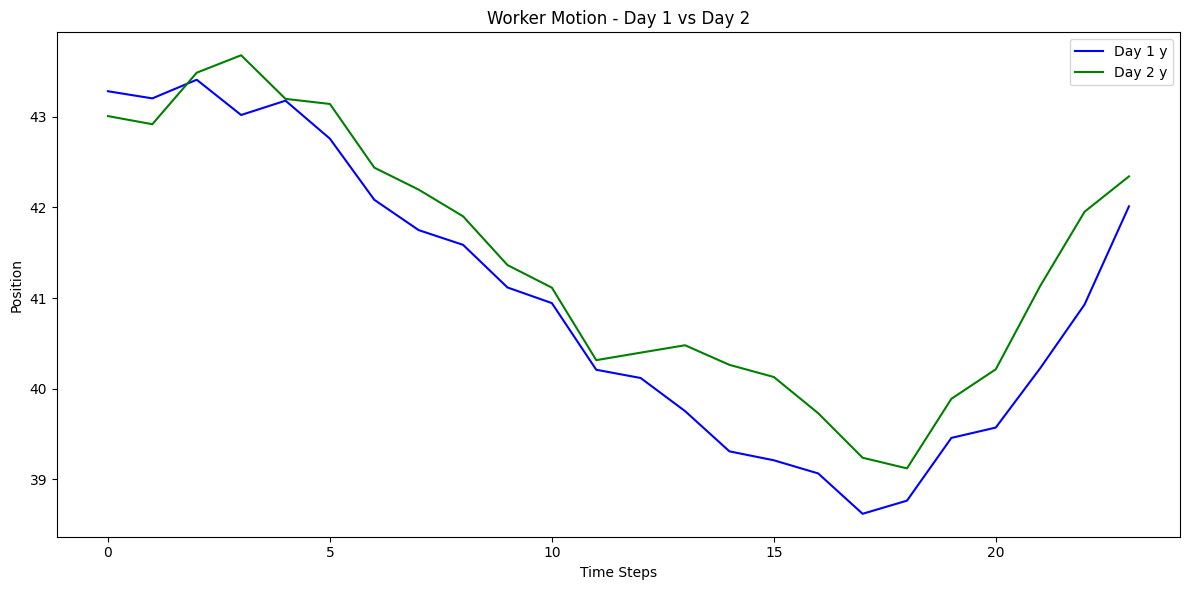

In [21]:
train_day_1 = tensor[0, :, :]
train_day_2 = tensor[4, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
# plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
plt.plot(train_day_1[:, 2], label='Day 1 y', color='blue')
# plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
plt.plot(train_day_2[:, 2], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [22]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (21, 2)
Time factors shape: (24, 2)
Feature factors shape: (4, 2)


In [23]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (21, 24, 4)
Reconstructed tensor shape: (21, 24, 4)


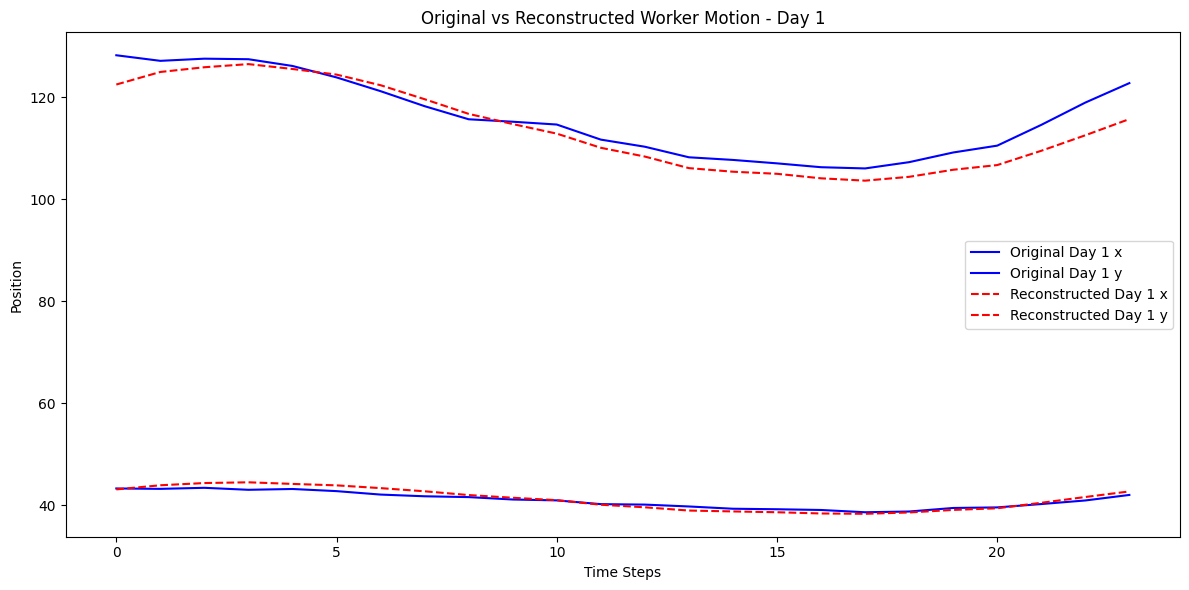

In [24]:
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
plt.plot(train_day_1[:, 2], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
plt.plot(train_day_1_reconstructed[:, 2], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [25]:
from statsmodels.tsa.ar_model import AutoReg

N_fd = 6  # forecast next 6 days
forecast_day_factors = np.zeros((N_fd, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=N_fd)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((N_fd, TIME, 4))
for i in range(N_fd):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

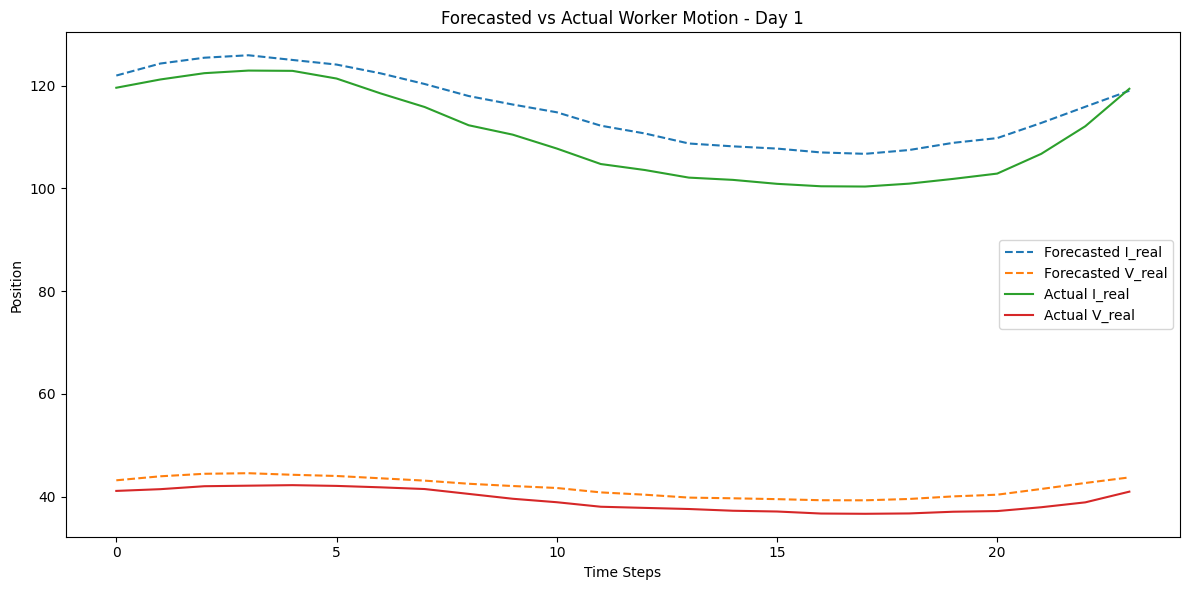

In [26]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_I_real = forecasted_day_1[:, 0]
forecasted_day_1_V_real = forecasted_day_1[:, 2]

test_day_1 = tensor[21, :, :]
real_of_forecast_day_1_I_real = test_day_1[:, 0]
real_of_forecast_day_1_V_real = test_day_1[:, 2]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_I_real, label='Forecasted I_real', linestyle='--')
plt.plot(forecasted_day_1_V_real, label='Forecasted V_real', linestyle='--')
plt.plot(real_of_forecast_day_1_I_real, label='Actual I_real')
plt.plot(real_of_forecast_day_1_V_real, label='Actual V_real')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

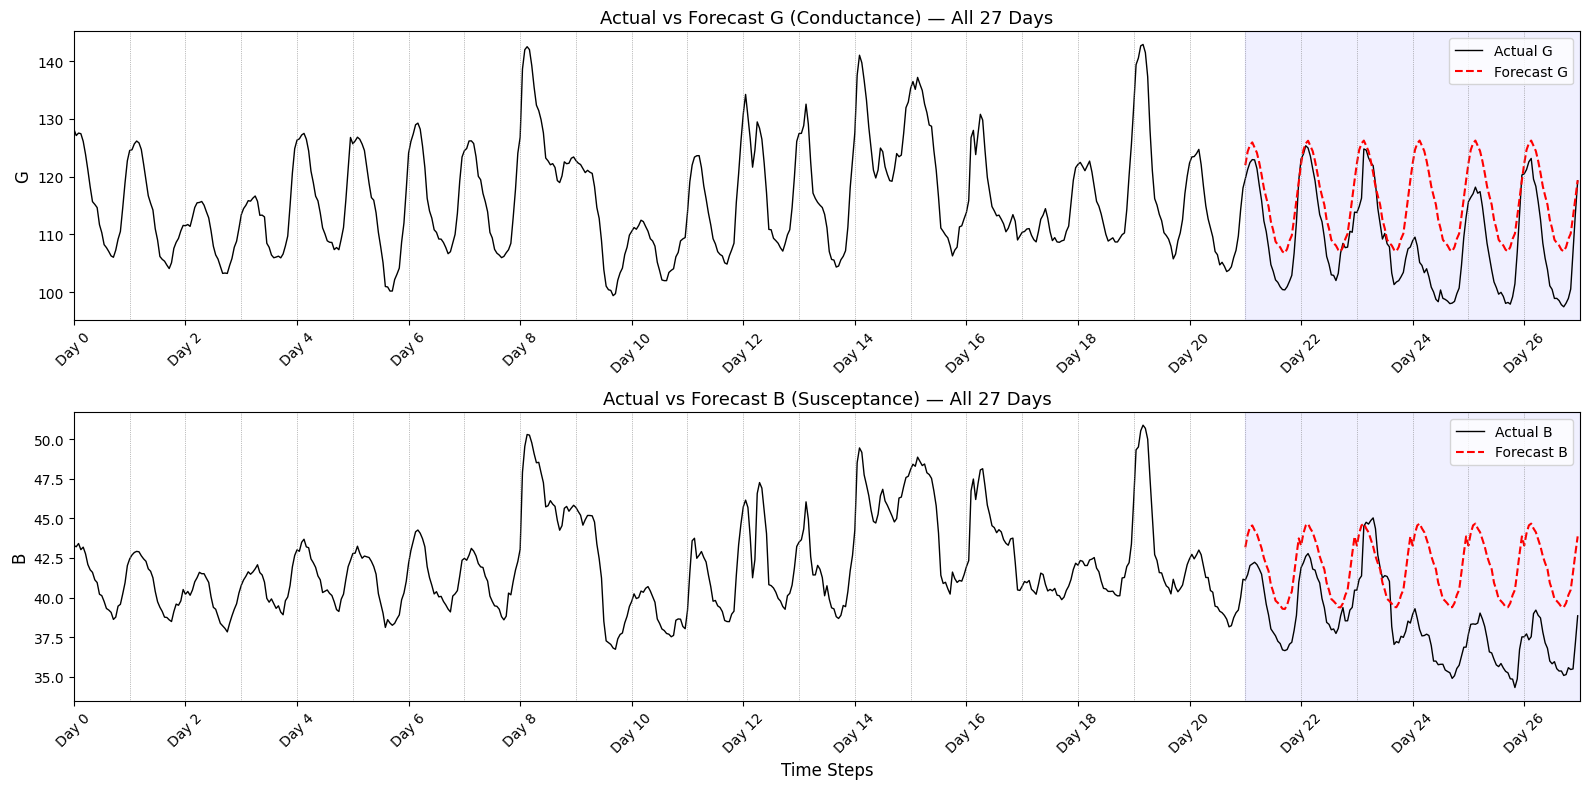

In [27]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, 4)  # (648, 4) actual for all 27 days
forecast_series = forecast_tensor.reshape(-1, 4)  # (144, 4) forecast for days 22-27

T = DAYS * TIME
x = np.arange(T)
forecast_start = 21 * TIME
x_forecast = np.arange(forecast_start, forecast_start + N_fd * TIME)

plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, DAYS + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('G', fontsize=12)
plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
plt.plot(x, full_series[:, 2], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 2], 'r--', lw=1.5, label='Forecast B')
for d in range(1, DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, DAYS + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

Anomalous points: 60 / 144


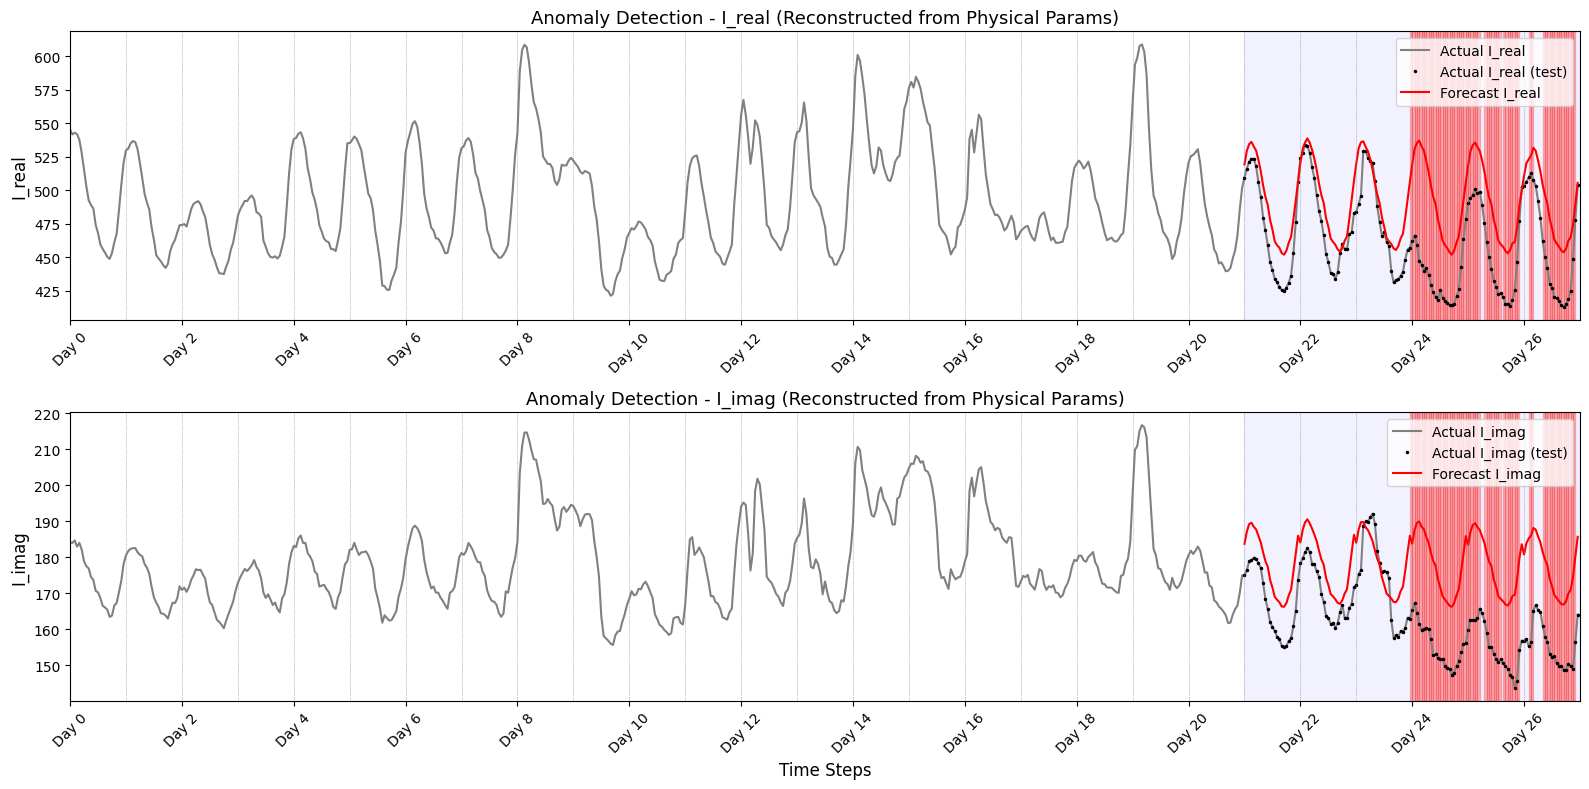

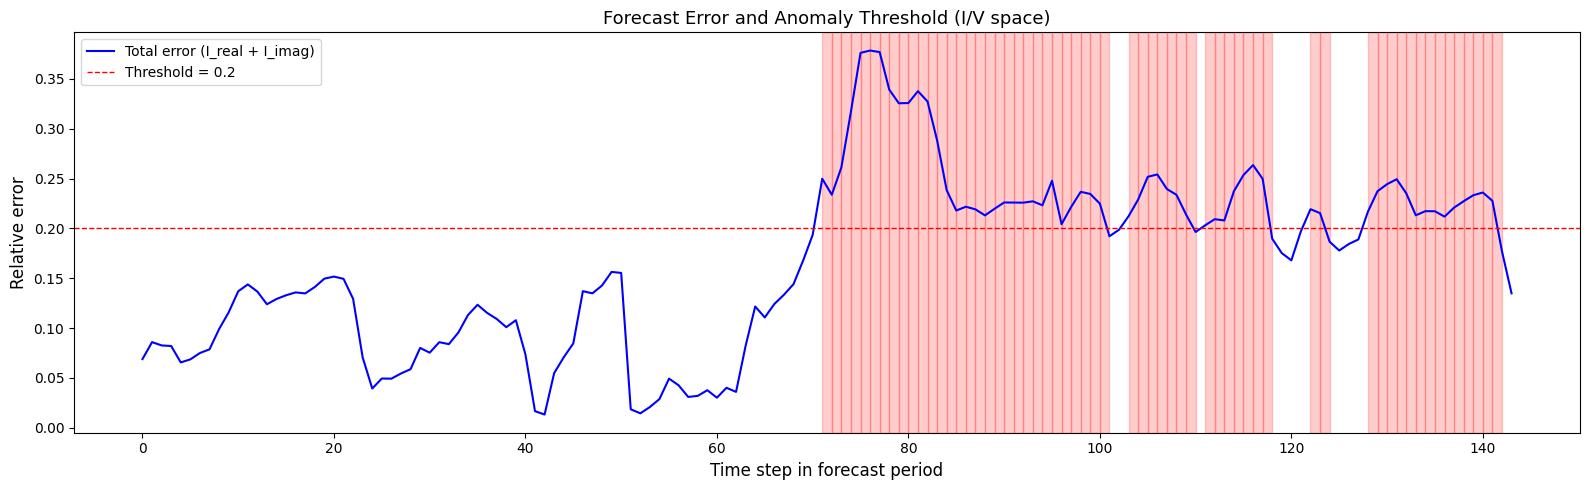

In [28]:
# --- Reload data & rebuild tensor (in case kernel was reset) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from numpy.linalg import lstsq
from tensorly.decomposition import parafac
from tensorly import cp_to_tensor
from statsmodels.tsa.ar_model import AutoReg

df = pd.read_csv('int3_data_converted.csv')

# Noise reduction
for col in ['I_real', 'I_imag', 'V_real', 'V_imag']:
    df[col] = gaussian_filter1d(df[col], sigma=0.5)

WINDOW_SIZE, HALF_WIN, sigma_w = 5, 2, 0.5

def windowed_data(series, tt, half_win, sigma):
    n = len(series)
    full = norm.pdf(np.arange(-half_win, half_win + 1), 0, sigma)
    if tt < half_win:
        return series[:tt + half_win + 1] * full[half_win - tt:]
    elif tt >= n - half_win:
        return series[tt - half_win:] * full[:n - tt + half_win]
    return series[tt - half_win:tt + half_win + 1] * full

TOTAL_POINTS, DAYS, TIME = 671, 27, 671 // 27
tensor = np.zeros((DAYS, TIME, 4))
for day in range(DAYS):
    s = day * TIME; e = s + TIME
    Vr, Ir, Ii = df['V_real'].values[s:e], df['I_real'].values[s:e], df['I_imag'].values[s:e]
    for tt in range(TIME):
        Vrw = windowed_data(Vr, tt, HALF_WIN, sigma_w)
        Irw = windowed_data(Ir, tt, HALF_WIN, sigma_w)
        Iiw = windowed_data(Ii, tt, HALF_WIN, sigma_w)
        A = np.column_stack([np.ones_like(Vrw), Vrw])
        ar, G = lstsq(A, Irw, rcond=None)[0]
        ai, B = lstsq(A, Iiw, rcond=None)[0]
        tensor[day, tt] = [G, ar, B, ai]

# CP decomposition
R = 2
weights, factors = parafac(tensor[:21], rank=R, normalize_factors=True)
day_f, time_f, feat_f = factors

# AR forecast on day factors
N_fd = 6
fc_df = np.zeros((N_fd, R))
for r in range(R):
    m = AutoReg(day_f[:, r], lags=1, old_names=False).fit()
    fc_df[:, r] = m.forecast(steps=N_fd)

forecast_tensor = np.zeros((N_fd, TIME, 4))
for i in range(N_fd):
    for r in range(R):
        forecast_tensor[i] += weights[r] * np.outer(fc_df[i, r] * time_f[:, r], feat_f[:, r])

# --- Convert forecasted physical params back to I/V ---
# Model: I_real = alpha_r + G * V_real,  I_imag = alpha_i + B * V_real
Vr_full = df['V_real'].values[:DAYS * TIME]

forecast_start = 21 * TIME
Vr_fc = Vr_full[forecast_start:]

# Reconstruct I from physical params for the full period
G_all = tensor[:, :, 0].reshape(-1)
ar_all = tensor[:, :, 1].reshape(-1)
B_all = tensor[:, :, 2].reshape(-1)
ai_all = tensor[:, :, 3].reshape(-1)

I_actual = ar_all + G_all * Vr_full
Ii_actual = ai_all + B_all * Vr_full

# Forecast physical params
G_fc = forecast_tensor[:, :, 0].reshape(-1)
ar_fc = forecast_tensor[:, :, 1].reshape(-1)
B_fc = forecast_tensor[:, :, 2].reshape(-1)
ai_fc = forecast_tensor[:, :, 3].reshape(-1)

I_fc = ar_fc + G_fc * Vr_fc
Ii_fc = ai_fc + B_fc * Vr_fc

# Actual I/V for forecast period
I_test = ar_all[forecast_start:] + G_all[forecast_start:] * Vr_fc
Ii_test = ai_all[forecast_start:] + B_all[forecast_start:] * Vr_fc

# --- Anomaly Detection on reconstructed I/V ---
err_I = np.abs(I_test - I_fc) / np.abs(I_test + 1e-10)
err_Ii = np.abs(Ii_test - Ii_fc) / np.abs(Ii_test + 1e-10)
err_tot = err_I + err_Ii

cutoff_val = 0.2
anomaly_idx = np.where(err_tot >= cutoff_val)[0]

print(f"Anomalous points: {len(anomaly_idx)} / {len(err_tot)}")

T_full = DAYS * TIME
x_full = np.arange(T_full)
x_fc = np.arange(forecast_start, T_full)

plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
plt.plot(x_full, I_actual, color='gray', lw=1.5, label='Actual I_real')
plt.plot(x_fc, I_test, 'k.', ms=3, label='Actual I_real (test)')
plt.plot(x_fc, I_fc, 'r-', lw=1.5, label='Forecast I_real')
for d in range(1, DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T_full, alpha=0.05, color='blue')
for idx in anomaly_idx:
    plt.axvspan(forecast_start + idx, forecast_start + idx + 1, alpha=0.25, color='red')
plt.xticks(np.arange(0, T_full + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, DAYS + 1, 2)], rotation=45)
plt.xlim(0, T_full)
plt.ylabel('I_real', fontsize=12)
plt.title('Anomaly Detection - I_real (Reconstructed from Physical Params)', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
plt.plot(x_full, Ii_actual, color='gray', lw=1.5, label='Actual I_imag')
plt.plot(x_fc, Ii_test, 'k.', ms=3, label='Actual I_imag (test)')
plt.plot(x_fc, Ii_fc, 'r-', lw=1.5, label='Forecast I_imag')
for d in range(1, DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T_full, alpha=0.05, color='blue')
for idx in anomaly_idx:
    plt.axvspan(forecast_start + idx, forecast_start + idx + 1, alpha=0.25, color='red')
plt.xticks(np.arange(0, T_full + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, DAYS + 1, 2)], rotation=45)
plt.xlim(0, T_full)
plt.ylabel('I_imag', fontsize=12)
plt.title('Anomaly Detection - I_imag (Reconstructed from Physical Params)', fontsize=13)
plt.legend(loc='upper right')

plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

# --- Error Plot ---
plt.figure(figsize=(16, 5))
plt.plot(err_tot, 'b-', lw=1.5, label='Total error (I_real + I_imag)')
plt.axhline(cutoff_val, color='r', ls='--', lw=1, label=f'Threshold = {cutoff_val}')
for idx in anomaly_idx:
    plt.axvspan(idx, idx + 1, alpha=0.2, color='red')
plt.xlabel('Time step in forecast period', fontsize=12)
plt.ylabel('Relative error', fontsize=12)
plt.title('Forecast Error and Anomaly Threshold (I/V space)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()
